In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("employees.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       101 non-null    object 
 1   Name              100 non-null    object 
 2   Department        101 non-null    object 
 3   Salary            100 non-null    float64
 4   Experience_Years  98 non-null     float64
 5   Join_Date         101 non-null    object 
dtypes: float64(2), object(4)
memory usage: 4.9+ KB


In [4]:
data["Age"] = pd.Series(np.linspace(18,55,data.Name.index.stop)).sample(data.Name.index.stop)
# data.Name.index.stop

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       101 non-null    object 
 1   Name              100 non-null    object 
 2   Department        101 non-null    object 
 3   Salary            100 non-null    float64
 4   Experience_Years  98 non-null     float64
 5   Join_Date         101 non-null    object 
 6   Age               101 non-null    float64
dtypes: float64(3), object(4)
memory usage: 5.7+ KB


In [6]:
data.head()

,Employee_ID,Name,Department,Salary,Experience_Years,Join_Date,Age
0,E001,Ali Khan,IT,55000.0,3.0,2021-05-12,18.00
1,E002,Sara Ahmed,HR,48000.0,5.0,2019/03/10,18.37
2,E003,Usman Malik,Finance,62000.0,7.0,2018-07-01,18.74
3,E004,Ahmed Raza,IT,NaN,2.0,2022-01-15,19.11
4,E005,Fatima Noor,Marketing,45000.0,4.0,2020-09-09,19.48


In [7]:
data.tail()

,Employee_ID,Name,Department,Salary,Experience_Years,Join_Date,Age
96,E096,James Smith,IT,61000.0,8.0,2016-04-05,53.52
97,E097,Ayesha Khan,HR,47000.0,3.0,2021-11-01,53.89
98,E098,Zara Malik,Marketing,45000.0,4.0,2020-09-09,54.26
99,E099,Bilal Shaikh,Finance,52000.0,4.0,2020-06-25,54.63
100,E100,Maria Ali,Finance,51000.0,3.0,2019-04-20,55.00


In [8]:
emp  = pd.read_excel("employee_data.xlsx")

In [9]:
emp.head()

,First Name,Last Name,Gender,Age,Salary,Expenditure,Savings,Expenditure Percentage,Savings Percentage
0,Aditi,Mishra,Female,35,80000,65000,15000,0.812500,0.187500
1,Sona,Singh,Female,35,70000,58000,12000,0.828571,0.171429
2,Devi,Thakur,Female,36,65000,60000,5000,0.923077,0.076923
3,Anjali,Kaur,Female,42,62000,50000,12000,0.806452,0.193548
4,Sahil,Deshmukh,Male,29,62000,57000,5000,0.919355,0.080645


In [10]:
emp.Age.min(),emp.Age.max()

(25, 52)

In [11]:
bins = [25,35,40,55]

In [12]:
cats = pd.cut(emp.Age,bins,labels=["chota", "darmiyana", "bara"])

In [13]:
emp["age_categories"] = cats

In [14]:
emp["age_categories"].value_counts()

age_categories
chota        15
bara         13
darmiyana     6
Name: count, dtype: int64

In [15]:
emp.sample(5)

,First Name,Last Name,Gender,Age,Salary,Expenditure,Savings,Expenditure Percentage,Savings Percentage,age_categories
8,Jaya,Mehta,Female,28,52000,46000,6000,0.884615,0.115385,chota
5,Adhira,Das,Male,42,62000,59000,3000,0.951613,0.048387,bara
11,Raghav,Verma,Male,28,51000,49000,2000,0.960784,0.039216,chota
3,Anjali,Kaur,Female,42,62000,50000,12000,0.806452,0.193548,bara
12,Amitabh,Joshi,Male,36,51000,50000,1000,0.980392,0.019608,darmiyana


In [16]:
emp.Salary.min(),emp.Salary.max()

(24100, 80000)

In [17]:
salary_bins = [24000,44000,54000,80000] # 24000 -> 44000 Low , 44000 -> 54000 Avrage, 54000 -> 80000 high

In [18]:
salary_cats = pd.cut(emp.Salary,salary_bins,labels=["Low_Salary", "Avarage_Salary","High_Salary"])

In [19]:
emp["Salary_category"] = salary_cats

In [20]:
emp.sample(5)

,First Name,Last Name,Gender,Age,Salary,Expenditure,Savings,Expenditure Percentage,Savings Percentage,age_categories,Salary_category
5,Adhira,Das,Male,42,62000,59000,3000,0.951613,0.048387,bara,High_Salary
18,Atharva,Das,Male,29,41000,35000,6000,0.853659,0.146341,chota,Low_Salary
22,Ishaan,Sharma,Male,35,35000,25000,10000,0.714286,0.285714,chota,Low_Salary
1,Sona,Singh,Female,35,70000,58000,12000,0.828571,0.171429,chota,High_Salary
14,Tulsi,Acharya,Female,40,45200,40000,5200,0.884956,0.115044,darmiyana,Avarage_Salary


In [21]:
emp["Salary_category"].value_counts()

Salary_category
Low_Salary        19
Avarage_Salary    10
High_Salary        6
Name: count, dtype: int64

# Detecting and Filtering Outliers

In [22]:
import numpy as np

In [23]:
def outlier_detector(col):
    
    q1 = np.percentile(col, 25)
    q3 = np.percentile(col,75)
    IQR = q3 - q1
    lower_boundary = q1 - 1.5*IQR
    upper_boundary = q3 + 1.5*IQR
    return lower_boundary,upper_boundary

In [24]:
example_array =  pd.Series(np.random.random_sample(1000)*1000)
example_array 
outliers_list = pd.Series([1,2,3,4000,2000,190000])
example_array = pd.concat([example_array, outliers_list] ,ignore_index=True)
example_array

0          371.457986
1          963.721874
2          450.008679
3          580.126342
4          487.164707
            ...      
1001         2.000000
1002         3.000000
1003      4000.000000
1004      2000.000000
1005    190000.000000
Length: 1006, dtype: float64

In [25]:
s1 = pd.Series([1, 2, 3])
s2 = pd.Series([4, 5, 6])

# Vertical concatenation (stacking rows)
stacked = pd.concat([s1, s2])
stacked

0    1
1    2
2    3
0    4
1    5
2    6
dtype: int64

In [26]:
lb,ub =outlier_detector(example_array)

In [27]:
print("Lower boundary: ",ub)

Lower boundary:  1503.48413741624


In [28]:
import seaborn as sns

<Axes: >

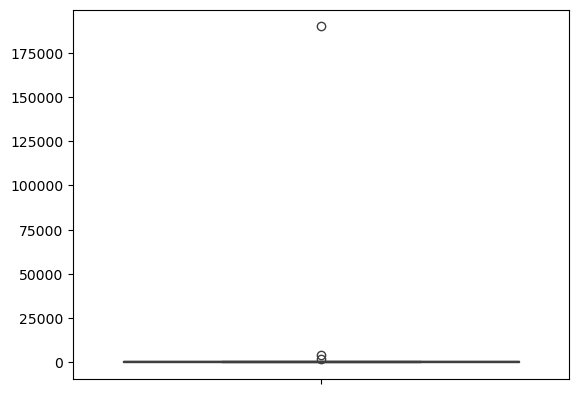

In [29]:
sns.boxplot(example_array)

In [32]:
example_array = example_array[(example_array <ub) &  (example_array > lb)]

<Axes: >

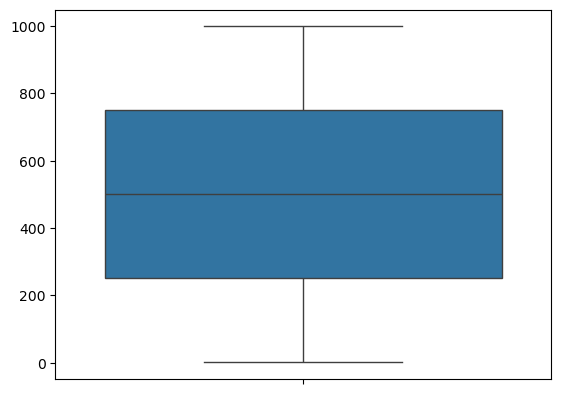

In [33]:
sns.boxplot(example_array)

# Permutation and Random Sampling

In [34]:
df = df = pd.DataFrame(np.arange(5 * 4).reshape((5, 4)))

In [36]:
sampler = np.random.permutation(5)
sampler

array([2, 1, 0, 3, 4])

In [37]:
df.take(sampler)

,0,1,2,3
2,8,9,10,11
1,4,5,6,7
0,0,1,2,3
3,12,13,14,15
4,16,17,18,19


In [38]:
# short Trick

df.sample(5)

,0,1,2,3
3,12,13,14,15
4,16,17,18,19
2,8,9,10,11
1,4,5,6,7
0,0,1,2,3


In [39]:
emp.sample(10)

,First Name,Last Name,Gender,Age,Salary,Expenditure,Savings,Expenditure Percentage,Savings Percentage,age_categories,Salary_category
29,Agastya,Joshi,Male,50,25500,20000,5500,0.784314,0.215686,bara,Low_Salary
7,Amar,Rao,Male,52,52100,46000,6100,0.882917,0.117083,bara,Avarage_Salary
25,Shaila,Gupta,Female,51,35000,34000,1000,0.971429,0.028571,bara,Low_Salary
9,Candy,Patel,Female,35,52000,40000,12000,0.769231,0.230769,chota,Avarage_Salary
3,Anjali,Kaur,Female,42,62000,50000,12000,0.806452,0.193548,bara,High_Salary
23,Dhruva,Yadav,Male,42,35000,22000,13000,0.628571,0.371429,bara,Low_Salary
18,Atharva,Das,Male,29,41000,35000,6000,0.853659,0.146341,chota,Low_Salary
2,Devi,Thakur,Female,36,65000,60000,5000,0.923077,0.076923,darmiyana,High_Salary
16,Nil,Kumar,Male,44,42000,38000,4000,0.904762,0.095238,bara,Low_Salary
10,Sudhir,Mishra,Male,35,52000,47000,5000,0.903846,0.096154,chota,Avarage_Salary


In [45]:
#  ADD Department column in employees data
emp['Departments'] = np.random.choice(['IT', 'Finance', 'Marketing',"HR", "Accounting", "Sales"], size=len(emp))

# Computing Indicator/Dummy Variables

In [44]:
emp.head()

,First Name,Last Name,Gender,Age,Salary,Expenditure,Savings,Expenditure Percentage,Savings Percentage,age_categories,Salary_category,Departments
0,Aditi,Mishra,Female,35,80000,65000,15000,0.812500,0.187500,chota,High_Salary,Marketing
1,Sona,Singh,Female,35,70000,58000,12000,0.828571,0.171429,chota,High_Salary,Marketing
2,Devi,Thakur,Female,36,65000,60000,5000,0.923077,0.076923,darmiyana,High_Salary,Accounting
3,Anjali,Kaur,Female,42,62000,50000,12000,0.806452,0.193548,bara,High_Salary,Sales
4,Sahil,Deshmukh,Male,29,62000,57000,5000,0.919355,0.080645,chota,High_Salary,Marketing


In [46]:
df = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'b'],
'data1': range(6)})

In [48]:
pd.get_dummies(df["key"], dtype=int)

,a,b,c
0,0,1,0
1,0,1,0
2,1,0,0
3,0,0,1
4,1,0,0
5,0,1,0


In [51]:
pd.get_dummies(emp.Departments, dtype=int).head(5)

,Accounting,Finance,HR,IT,Marketing,Sales
0,0,1,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,1,0
3,0,1,0,0,0,0
4,0,0,0,0,0,1
